In [1]:
from hyrax import Hyrax
from pathlib import Path
import re
import pandas as pd
import numpy as np

In [2]:
def load_external_catalog(catalog_path: str) -> pd.DataFrame:
    """Load an overlay catalog from parquet or FITS.

    Parameters
    ----------
    catalog_path : str
        Path to the catalog file.

    Returns
    -------
    pd.DataFrame
        DataFrame containing catalog rows and columns.
    """
    catalog_path = Path(catalog_path)
    suffix = catalog_path.suffix.lower()

    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(catalog_path)

    if suffix in {".fits", ".fit", ".fts"}:
        from astropy.table import Table

        return Table.read(catalog_path).to_pandas()

    raise ValueError(
        f"Unsupported catalog format '{suffix}'. Use parquet or FITS."
    )

In [3]:
def extract_umap_info(x,y,base_directory="/Users/diegomiura/research/Hyrax-Research/test_dir_100images/hyrax_runs"):
  """Extract UMAP directory from 3dumap output file."""

  # Construct paths
  run_dir = Path(base_directory) / f"run{x}"
  dumap_name = f"udb{x}_{y}"

  dumap_output_file = run_dir / f"{dumap_name}.txt"
  dumap_toml_file = run_dir / f"{dumap_name}.toml"
    
  try:
      with open(dumap_output_file, 'r') as f:
          content = f.read()

      # Look for the UMAP results save pattern
      pattern = r'Saving UMAP results to (.+)'
      match = re.search(pattern, content)

      if match:
          umap_dir = match.group(1).strip()
          return umap_dir, dumap_toml_file
      else:
          raise ValueError(f"Could not find UMAP directory in {dumap_output_file}")

  except FileNotFoundError:
      raise FileNotFoundError(f"3dumap output file not found: {dumap_output_file}")

In [4]:
# h.config["visualize"]["display_images"] = True
# h.config["visualize"]["image_mode"] = "color"
# h.config["visualize"]["fits_rgb_bands"] = ["I", "R", "G"]

# h.visualize(
#     make_lupton_rgb_opts={"stretch": 0.1, "Q": 8},
#     # overlays=...
# )

In [5]:
catalog = load_external_catalog("/Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_images/catalog.fits")

In [6]:
list(catalog.columns)

['object_id',
 'filename',
 'filter',
 'sim',
 'snapshot',
 'subhalo',
 'dbid',
 'has_merger_row',
 'has_major_past_1gyr',
 'has_major_future_1gyr',
 'has_minor_past_1gyr',
 'has_minor_future_1gyr',
 'has_mini_past_1gyr',
 'has_mini_future_1gyr',
 'major_count_since_1gyr',
 'major_count_until_1gyr',
 'minor_count_since_1gyr',
 'minor_count_until_1gyr',
 'mini_count_since_1gyr',
 'mini_count_until_1gyr',
 'major_time_since_merger',
 'major_time_until_merger',
 'minor_time_since_merger',
 'minor_time_until_merger',
 'mini_time_since_merger',
 'mini_time_until_merger',
 'MaxMassSnap_stars',
 'MaxMassType_stars',
 'MaxMassInRadSnap_stars',
 'MaxMassInRadType_stars',
 'Major_CountSinceMainLeafProgenitor',
 'Major_CountSinceHalfScaleFactor',
 'Major_CountSince250Myr',
 'Major_CountSince500Myr',
 'Major_CountSince1Gyr',
 'Major_CountSince2Gyr',
 'Major_CountSince3Gyr',
 'Major_FreqencySinceMainLeafProgenitor',
 'Major_PastSnapNum',
 'Major_PastSubfindID',
 'Major_PastMassRatio',
 'Major_TimeS

In [7]:
mask_major = catalog["Major_TimeSinceMerger"] < 3

mask_minor = (
    (catalog["Minor_TimeSinceMerger"] < 3) |
    (catalog["Major_TimeSinceMerger"] < 3)
)

mask_mini = (
    (catalog["Mini_TimeSinceMerger"] < 3) |
    (catalog["Minor_TimeSinceMerger"] < 3) |
    (catalog["Major_TimeSinceMerger"] < 3)
)

cols = [
    "object_id",
    "Major_TimeSinceMerger",
    "Major_CountSince250Myr",
    "Major_CountSince500Myr",
    "Major_CountSince1Gyr",
    "Major_CountSince2Gyr",
    "Major_CountSince3Gyr",
    "Minor_TimeSinceMerger",
    "Minor_CountSince250Myr",
    "Minor_CountSince500Myr",
    "Minor_CountSince1Gyr",
    "Minor_CountSince2Gyr",
    "Minor_CountSince3Gyr",
]

masked_catalog_major = catalog.loc[mask_major, cols]
masked_catalog_minor = catalog.loc[mask_minor, cols]
masked_catalog_mini = catalog.loc[mask_mini, cols]

print(f"{len(masked_catalog_major)} have had at least 1 major merger in the last 3 Gyr out of {len(catalog)}")
print(f"{len(masked_catalog_major) / len(catalog) * 100:.2f}%")
print("__________")

print(f"{len(masked_catalog_minor)} have had at least 1 minor or major merger in the last 3 Gyr out of {len(catalog)}")
print(f"{len(masked_catalog_minor) / len(catalog) * 100:.2f}%")
print("__________")

print(f"{len(masked_catalog_mini)} have had at least 1 mini, minor, or major merger in the last 3 Gyr out of {len(catalog)}")
print(f"{len(masked_catalog_mini) / len(catalog) * 100:.2f}%")
print("__________")

60 have had at least 1 major merger in the last 3 Gyr out of 500
12.00%
__________
140 have had at least 1 minor or major merger in the last 3 Gyr out of 500
28.00%
__________
235 have had at least 1 mini, minor, or major merger in the last 3 Gyr out of 500
47.00%
__________


In [8]:
np.min(catalog["Major_TimeSinceMerger"][catalog["Major_TimeSinceMerger"]>0]), np.max(catalog["Major_TimeSinceMerger"][catalog["Major_TimeSinceMerger"].notnull()])

(np.float64(0.326906), np.float64(8.91145))

[2026-05-19 14:18:34,159 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.nn.MSELoss.
[2026-05-19 14:18:34,159 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.SGD.
[2026-05-19 14:18:34,165 hyrax.config_utils:WARNING] Cannot find default_config.toml for umap.UMAP.
[2026-05-19 14:18:34,171 hyrax.config_utils:WARNING] Runtime config contains key or section 'base_channel_size' which has no default defined. All configuration keys and sections must be defined in /Users/diegomiura/research/hyrax/src/hyrax/hyrax_default_config.toml
[2026-05-19 14:18:34,179 hyrax.config_utils:WARNING] Runtime config contains key or section 'latent_dim' which has no default defined. All configuration keys and sections must be defined in /Users/diegomiura/research/hyrax/src/hyrax/hyrax_default_config.toml
[2026-05-19 14:18:34,180 hyrax.config_utils:WARNING] Runtime config contains key or section 'final_layer' which has no default defined. All configuration keys and

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
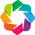

BokehModel(combine_events=True, render_bundle={'docs_json': {'6feb4d80-96ae-498e-a80a-bd16ca24b8ff': {'version…

In [9]:
run = 1
expt = 1

h = Hyrax(config_file=extract_umap_info(run,expt)[1])
catalog_df = catalog.to_pandas() if hasattr(catalog, "to_pandas") else pd.DataFrame(catalog)
id_col = "object_id"  # change this if your catalog uses a different object-id column

# h.set_config("visualize.display_images", True)

h.config["visualize"]["display_images"] = True
h.config["visualize"]["image_mode"] = "color"
h.config["visualize"]["fits_rgb_bands"] = ["I", "R", "G"]


overlays = [
    {
        "catalog": catalog_df[catalog_df["has_major_past_1gyr"] >= 0.5],
        "id_column": id_col,
        "color": "red",
        "marker": "x",
        "label": "Major past 1 Gyr",
    },
    {
        "catalog": catalog_df[catalog_df["has_minor_past_1gyr"] >= 0.5],
        "id_column": id_col,
        "color": "green",
        "marker": "s",
        "label": "Minor past 1 Gyr",
    },
    {
        "catalog": catalog_df[catalog_df["has_mini_past_1gyr"] >= 0.5],
        "id_column": id_col,
        "color": "blue",
        "marker": "+",
        "label": "Mini past 1 Gyr",
    },
]

pane, viz = h.visualize(
    make_lupton_rgb_opts={"stretch": 0.01, "Q": 10},
    input_dir=extract_umap_info(run,expt)[0],
    return_verb=True,
    width=550,
    height=550,
    overlays=overlays,
)

In [ ]:
h = Hyrax(config_file="/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/run5/udb5_7.toml")

h.set_config("visualize.display_images", True)

umap_dir = "/Users/diegomiura/research/Hyrax-Research/results/20260217-183809-umap-mO1j"


pane, viz = h.visualize(
    input_dir=umap_dir,
    return_verb=True,
    width=500,
    height=500,
)

# Break

In [ ]:
from hyrax import Hyrax
import matplotlib.pyplot as plt
import numpy as np

h = Hyrax()

h.set_config("model.name", "HyraxAutoencoderV2")
h.set_config("train.epochs", 20)
h.set_config("data_loader.batch_size", 32)
h.set_config("data_set.filter_catalog", "/Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_images/catalog.fits")
h.set_config("data_set.crop_to", [53,53])

data_dir = "/Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_images"

data_request_definition = {
    "train": {
        "data": {
            "dataset_class": "FitsImageDataSet",
            "data_location": data_dir,
            "primary_id_field": "object_id",
            "split_fraction": 0.8,
        },
    },
    "validate": {
        "data": {
            "dataset_class": "FitsImageDataSet",
            "data_location": data_dir,
            "primary_id_field": "object_id",
            "split_fraction": 0.2,
        },
    },
}
h.set_config("data_request", data_request_definition)

[2026-04-28 22:12:42,957 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.nn.CrossEntropyLoss.
[2026-04-28 22:12:42,957 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.SGD.
[2026-04-28 22:12:42,958 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.lr_scheduler.ExponentialLR.
[2026-04-28 22:12:42,958 hyrax.config_utils:WARNING] Cannot find default_config.toml for umap.UMAP.
[2026-04-28 22:12:42,969 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.nn.CrossEntropyLoss.
[2026-04-28 22:12:42,969 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.SGD.
[2026-04-28 22:12:42,969 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.lr_scheduler.ExponentialLR.
[2026-04-28 22:12:42,970 hyrax.config_utils:WARNING] Cannot find default_config.toml for umap.UMAP.
[2026-04-28 22:12:42,979 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.nn.

In [6]:
model = h.train()

[2026-04-28 22:12:44,476 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:12:44,509 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:12:44,527 hyrax.models.model_registry:INFO] Setting model's self.optimizer from config: torch.optim.SGD with arguments: {'lr': 0.01, 'momentum': 0.9}.
[2026-04-28 22:12:44,527 hyrax.models.model_registry:INFO] Setting model's self.criterion from config: torch.nn.CrossEntropyLoss with default arguments.
[2026-04-28 22:12:44,527 hyrax.models.model_registry:INFO] Setting model's self.scheduler from config: torch.optim.lr_scheduler.ExponentialLR
with arguments: {'gamma': 1}.
[2026-04-28 22:12:44,528 hyrax.verbs.train:INFO] Training model: HyraxAutoencoderV2
[2026-04-28 22:12:44,528 hyrax.verbs.train:INFO] Training dataset(s):
{'train': Name: data (primary dataset)
  Dataset class: FitsImageDataSet
  Data location: /Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_

 25%|##5       | 1/4 [00:00<?, ?it/s]

 25%|##5       | 1/4 [00:00<?, ?it/s]

 25%|##5       | 1/4 [00:00<?, ?it/s]

 25%|##5       | 1/4 [00:00<?, ?it/s]

...

 25%|##5       | 1/4 [00:00<?, ?it/s]

 25%|##5       | 1/4 [00:00<?, ?it/s]

 25%|##5       | 1/4 [00:00<?, ?it/s]

 25%|##5       | 1/4 [00:00<?, ?it/s]

[2026-04-28 22:12:49,882 hyrax.pytorch_ignite:INFO] Total training time: 5.23[s]
2026/04/28 22:12:49 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/28 22:12:49 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[2026-04-28 22:12:49,898 hyrax.verbs.train:INFO] Finished Training


In [8]:
h.config["data_loader"]["batch_size"] = 512

data_request_definition = {
    "infer": {
        "data": {
            "dataset_class": "FitsImageDataSet",
            "data_location": data_dir,
            "primary_id_field": "object_id",
        },
    },
}
h.set_config("data_request", data_request_definition)

inference_results = h.infer()

[2026-04-28 22:13:11,113 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.nn.CrossEntropyLoss.
[2026-04-28 22:13:11,113 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.SGD.
[2026-04-28 22:13:11,114 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.lr_scheduler.ExponentialLR.
[2026-04-28 22:13:11,114 hyrax.config_utils:WARNING] Cannot find default_config.toml for umap.UMAP.
[2026-04-28 22:13:11,157 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:11,338 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:11,366 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:11,638 hyrax.models.model_registry:INFO] Setting model's self.optimizer from config: torch.optim.SGD with arguments: {'lr': 0.01, 'momentum': 0.9}.
[2026-04-28 22:13:11,638 hyrax.models.model_registry:INFO] Setting model's self.criter

100%|##########| 1/1 [00:00<?, ?it/s]

[2026-04-28 22:13:12,128 hyrax.pytorch_ignite:INFO] Total evaluation time: 0.42[s]
[2026-04-28 22:13:12,142 hyrax.verbs.infer:INFO] Inference Complete.
[2026-04-28 22:13:12,232 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:12,261 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:12,468 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects


In [9]:
h.config["umap"]["UMAP"]["n_components"] = 2
h.umap()

[2026-04-28 22:13:32,355 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:32,382 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:32,410 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:32,412 hyrax.verbs.umap:INFO] Saving UMAP results to /Users/diegomiura/research/Hyrax-Research/results/20260428-221332-umap-FTvj
[2026-04-28 22:13:32,463 hyrax.verbs.umap:INFO] Fitting the UMAP
[2026-04-28 22:13:35,862 hyrax.verbs.umap:INFO] Saving fitted UMAP Reducer


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-04-28 22:13:37,272 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP
[2026-04-28 22:13:37,333 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:37,523 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:13:37,550 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects


In [11]:
from hyrax.config_utils import find_most_recent_results_dir

results_dir = str(find_most_recent_results_dir(h.config, "umap"))
data_request_definition = {
    "analysis": {
        "umap": {
            "dataset_class": "FitsImageDataSet",
            "data_location": results_dir,
            "primary_id_field": "object_id",
        },
    }
}
h.config["data_request"] = data_request_definition
umap_results = h.prepare()

[2026-04-28 22:14:30,547 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-04-28 22:14:30,549 hyrax.prepare:INFO] Finished Prepare


In [ ]:
out = np.array([umap_results["analysis"][i]["umap"]["data"] for i in range(len(umap_results["analysis"]))])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(out[:, 0], out[:, 1], s=5, alpha=0.6)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of HSC Latent Space")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/diegomiura/research/Hyrax-Research/results/20260428-221332-umap-FTvj/100_72_0_G_v2_hsc_realistic.fits'

# Break

[2026-06-19 20:18:18,114 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.nn.MSELoss.
[2026-06-19 20:18:18,115 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.optim.SGD.
[2026-06-19 20:18:18,115 hyrax.config_utils:WARNING] Cannot find default_config.toml for umap.UMAP.
[2026-06-19 20:18:18,118 hyrax.config_utils:WARNING] Runtime config contains key or section 'base_channel_size' which has no default defined. All configuration keys and sections must be defined in /Users/diegomiura/research/hyrax/src/hyrax/hyrax_default_config.toml
[2026-06-19 20:18:18,118 hyrax.config_utils:WARNING] Runtime config contains key or section 'latent_dim' which has no default defined. All configuration keys and sections must be defined in /Users/diegomiura/research/hyrax/src/hyrax/hyrax_default_config.toml
[2026-06-19 20:18:18,119 hyrax.config_utils:WARNING] Runtime config contains key or section 'final_layer' which has no default defined. All configuration keys and

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
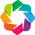

BokehModel(combine_events=True, render_bundle={'docs_json': {'6282109e-1ce2-4930-9020-7e066612cd2a': {'version…

In [12]:
run = 1
expt = 1

h = Hyrax(config_file=extract_umap_info(run, expt)[1])
catalog_df = catalog.to_pandas() if hasattr(catalog, "to_pandas") else pd.DataFrame(catalog)
id_col = "object_id"  # change this if your catalog uses a different object-id column

h.config["visualize"]["display_images"] = True
h.config["visualize"]["image_mode"] = "color"
h.config["visualize"]["fits_rgb_bands"] = ["I", "R", "G"]

lookback_gyr = 0.75

def merger_in_last_gyr(df, col, lookback_gyr=3.0):
    t = pd.to_numeric(df[col], errors="coerce")
    return t.notna() & (t >= 0.0) & (t <= lookback_gyr)

overlays = [
    {
        "catalog": catalog_df[merger_in_last_gyr(catalog_df, "Major_TimeSinceMerger", lookback_gyr)],
        "id_column": id_col,
        "color": "red",
        "marker": "x",
        "label": "Major past 3 Gyr",
    },
    # {
    #     "catalog": catalog_df[merger_in_last_gyr(catalog_df, "Minor_TimeSinceMerger", lookback_gyr)],
    #     "id_column": id_col,
    #     "color": "green",
    #     "marker": "s",
    #     "label": "Minor past 3 Gyr",
    # },
    # {
    #     "catalog": catalog_df[merger_in_last_gyr(catalog_df, "Mini_TimeSinceMerger", lookback_gyr)],
    #     "id_column": id_col,
    #     "color": "blue",
    #     "marker": "+",
    #     "label": "Mini past 3 Gyr",
    # },
]

pane, viz = h.visualize(
    make_lupton_rgb_opts={"stretch": 0.01, "Q": 10},
    input_dir=extract_umap_info(run, expt)[0],
    return_verb=True,
    width=550,
    height=550,
    overlays=overlays,
)